In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import torch
from kan import *
import torch.nn as nn
from sympy import symbols
import sympy as sp
from kan.utils import SYMBOLIC_LIB

In [2]:
R_VAL = 50.0 # meters, defined as a global constant for the turbine radius
RHO_VAL = 1.225 # kg/m^3, air density

In [3]:

def calculate_power_curve_vectorized(df, v_col='V', p_col='P', w_col='W', t_col='theta', 
                                     nbins=1000, sigma=3.5, rho=1.225, radius=40, cp_threshold=0.01):
    """
    Calcula curvas de referência e bandas sigma considerando apenas pontos onde
    o coeficiente de potência (Cp) é superior a um limiar mínimo (threshold).
    """
    
    # 1. Cálculo do Cp com proteção contra divisão por zero
    # Se V for muito próximo de zero, o Cp explode para o infinito; tratamos isso aqui.
    v_min_threshold = 0.5 
    v_filtered = df[v_col].where(df[v_col] > v_min_threshold, np.nan)
    
    cp = (2 * df[p_col]) / (rho * np.pi * (radius**2) * (v_filtered**3))
    
    # 2. Aplicar o Limiar (Threshold)
    # Remove valores negativos, zeros e ruído de baixa eficiência
    df_active = df[cp > cp_threshold].copy()
    
    if df_active.empty:
        raise ValueError(f"Nenhum dado com Cp > {cp_threshold} foi encontrado.")

    # 3. Configurações de Bins e Estatísticas
    lower_q = scipy.stats.norm.cdf(-sigma)
    upper_q = scipy.stats.norm.cdf(sigma)
    
    vmin, vmax = df_active[v_col].min(), df_active[v_col].max()
    bins = np.linspace(vmin, vmax, nbins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    df_active['V_bin'] = pd.cut(df_active[v_col], bins=bins, labels=bin_centers, include_lowest=True)

    agg_funcs = ['median', lambda x: x.quantile(lower_q), lambda x: x.quantile(upper_q)]
    
    def get_stats(col):
        # observed=False garante que todos os bins sejam representados no resultado
        agg = df_active.groupby('V_bin', observed=False)[col].agg(agg_funcs)
        agg.columns = ['median', 'lower', 'upper']
        return agg

    # Agregar estatísticas para as três variáveis principais
    p_agg = get_stats(p_col)
    w_agg = get_stats(w_col)
    t_agg = get_stats(t_col)

    def process_curve(series, is_power=False):
        # Reindex para alinhar com os centros dos bins e preencher buracos (ffill)
        curve = series.reindex(bin_centers).ffill()
        curve.iloc[0] = curve.iloc[0] if pd.notna(curve.iloc[0]) else 0
        
        if is_power:
            # Garante que a curva de potência não caia em ventos altos (Saturação)
            v_threshold = 15
            mask = curve.index >= v_threshold
            curve.loc[mask] = curve.loc[mask].cummax()
        return curve.to_numpy()

    return {
        'v_centers': bin_centers,
        'p': (process_curve(p_agg['median'], True), process_curve(p_agg['lower']), process_curve(p_agg['upper'])),
        'w': (process_curve(w_agg['median']), process_curve(w_agg['lower']), process_curve(w_agg['upper'])),
        't': (process_curve(t_agg['median']), process_curve(t_agg['lower']), process_curve(t_agg['upper']))
    }

In [4]:
df = pd.read_csv("/home/nail/Natali/Turbina_Expanded/All-1/turbine_plots_1/R80721_processed.csv")

In [5]:
r =  calculate_power_curve_vectorized(df)

In [6]:
device = 'cpu'

data = np.array([r['v_centers'], r['w'][0], r['t'][0]]).T
#mean_data = data.mean(axis=0)
#std_data = data.std(axis=0)
#data = (data - mean_data)/std_data

inputs = torch.tensor(data).float()

max_P = r['p'][0].max()
p = r['p'][0]/max_P

labels = torch.tensor(p).float().unsqueeze(1)


train_ratio = 0.8
num = inputs.shape[0]
np.random.seed(0)
n_train = max(1, int(num * train_ratio))
train_id = np.random.choice(num, n_train, replace=False)
test_id = list(set(np.arange(num)) - set(train_id))

dataset = {
    'train_input': inputs[train_id].to(device),
    'test_input': inputs[test_id].to(device),
    'train_label': labels[train_id].to(device),
    'test_label': labels[test_id].to(device)
}

In [8]:
model = KAN(width=[3,2,1],seed=0,k=3)

checkpoint directory created: ./model
saving model version 0.0


In [9]:
res = model.fit(dataset,  opt="LBFGS", lr=0.01, steps=1000,loss_fn = nn.MSELoss())

| train_loss: 6.65e-03 | test_loss: 7.43e-03 | reg: 8.06e+00 | : 100%|█| 1000/1000 [00:20<00:00, 47.

saving model version 0.1


<Figure size 640x480 with 0 Axes>

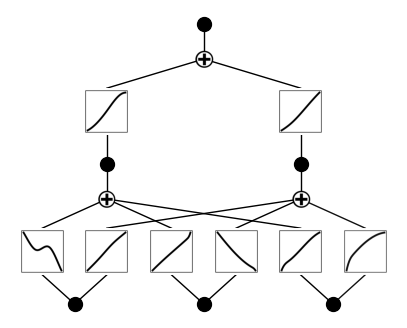

In [13]:
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt

plt.clf()

model.plot(beta=100) 

#plt.title("Topology of the Kolmogorov-Arnold Network [$3 \\to 2 \\to 1$]", 
#          fontsize=16, pad=20)

#plt.xlabel(r"Input Layers: $V$ (Wind), $W$ (RPM), $\Theta$ (Pitch)", 
#           fontsize=12, labelpad=15)
#plt.ylabel(r"Output Layer: Normalized Power ($P_{norm}$)", 
#           fontsize=12, labelpad=15)

file_name = 'KAN_topology_fixed.png'
plt.savefig(file_name, 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white')

plt.show()

In [15]:
model_prediction = model(inputs).detach().numpy()

In [16]:
lambda_real = (r['w'][0] * R_VAL) / r['v_centers']
cp_real = (2 * r['p'][0] ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)
cp_predicted = (2 * model_prediction[:,0] * max_P ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)

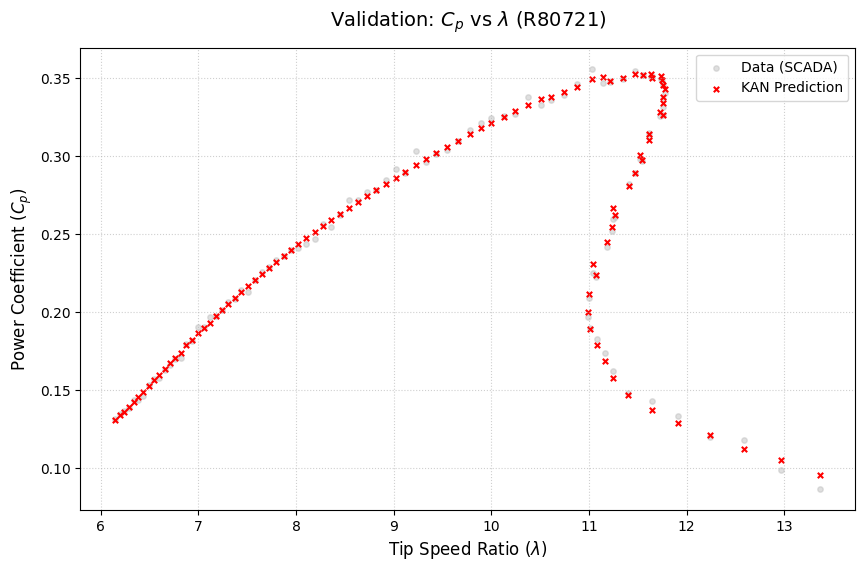

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(lambda_real[::10], cp_real[::10], label="Data (SCADA)", 
            color='silver', alpha=0.5, s=15, rasterized=True)

plt.scatter(lambda_real[::10], cp_predicted[::10], label="KAN Prediction", 
            color='red', marker='x', s=15)

plt.title(r"Validation: $C_p$ vs $\lambda$ (R80721)", fontsize=14, pad=15)
plt.xlabel(r"Tip Speed Ratio ($\lambda$)", fontsize=12)
plt.ylabel(r"Power Coefficient ($C_p$)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('Data_vs_KAN_80721.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [18]:
SYMBOLIC_LIB['sigmoid'] = (
    lambda x: torch.sigmoid(x),              # 1. PyTorch (Forward)
    lambda x: 1 / (1 + sympy.exp(-x)),       # 2. SymPy (Simbólico)
    3,                                       # 3. Complexidade
    lambda x, y_th: ((), torch.sigmoid(x))   # 4. Fitting estável (sem inversa)
)


In [19]:
model.prune()
minha_lib = ['0', 'x', 'x^1.5', 'x^2',  'tanh', 'exp', 'gaussian', 'sigmoid']
model.auto_symbolic(lib=minha_lib,)

saving model version 0.2
fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with x, r2=0.9978323578834534, c=1
fixing (0,1,0) with x, r2=0.9955688118934631, c=1
fixing (0,1,1) with exp, r2=0.9997438192367554, c=2
fixing (0,2,0) with x, r2=0.9944388270378113, c=1
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (1,0,0) with x, r2=0.9912123084068298, c=1
fixing (1,1,0) with x, r2=0.9958482980728149, c=1
saving model version 0.2


Best value at boundary.
r2 is 0.9964781999588013
saving model version 0.15
r2 is 0.9999851584434509
saving model version 0.16


<Figure size 640x480 with 0 Axes>

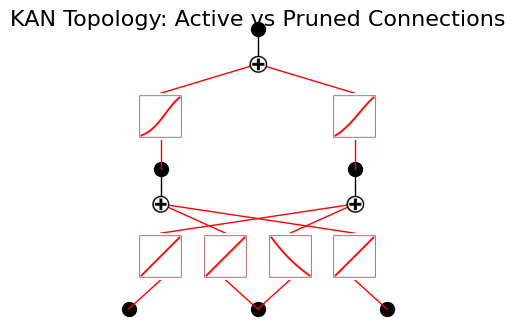

In [26]:
import matplotlib.pyplot as plt
import torch

model.fix_symbolic(1, 0, 0, 'sigmoid') 
model.fix_symbolic(1, 1, 0, 'gaussian') 

with torch.no_grad():
    model(dataset['train_input'])
    model.attribute()

plt.clf()
model.plot(beta=150) 

plt.title(r"KAN Topology: Active vs Pruned Connections", fontsize=16, pad=20)
plt.xlabel(r"Input Layers ($V, W, \Theta$)", fontsize=12, labelpad=15)
plt.ylabel(r"Output Layer ($P_{norm}$)", fontsize=12, labelpad=15)

plt.savefig('my_plot_prune.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

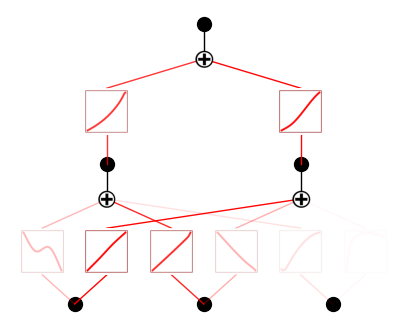

In [20]:
model.plot()

In [21]:
plt.savefig('my_plot_prune.png', dpi=300, bbox_inches='tight') # Сохраняем

<Figure size 640x480 with 0 Axes>

In [22]:
#s = [ (s*std_data[i])-mean_data[i] for i, s in enumerate(symbols("V W theta"))]
kan_formula = model.symbolic_formula(var=symbols("V W theta"))[0][0]

In [23]:
print(kan_formula)

7.82382309436798 - 1.06752490997314*exp(-0.361175735945252*(-0.177391057198365*V - 0.835972860605123*(1 - 0.262907348126976*W)**2 + 1)**2) - 6.84700536727905/(0.00155444942864371*exp(2.08671466865994*W + 1.5501404058823*theta) + 1)


In [24]:
# Ваша формула (предположим, она уже в переменной kan_formula)
# Если формула — это объект, преобразуем её в строку: str(kan_formula)

file_path = "formula_1_output.tex"

with open(file_path, "w", encoding="utf-8") as f:
    # Добавляем окружение equation для удобства вставки в статью
    f.write("\\begin{equation}\n")
    f.write(str(kan_formula))
    f.write("\n\\end{equation}")

print(f"Формула успешно сохранена в файл: {file_path}")

Формула успешно сохранена в файл: formula_1_output.tex


In [25]:
import sympy as sp
cp_numerical = sp.lambdify(symbols("V W theta"), kan_formula, 'numpy')


P_formula = cp_numerical(data[:,0], data[:,1], data[:,2])
#P_formula = P_formula * 0.19778233 
cp_formula = (2 * P_formula * max_P ) / (RHO_VAL * np.pi * (R_VAL**2) *  r['v_centers']**3)

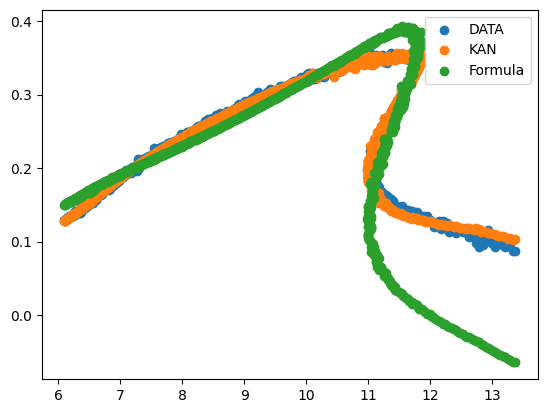

In [26]:
plt.scatter(lambda_real, cp_real,label="DATA")
plt.scatter(lambda_real, cp_predicted,label="KAN")
plt.scatter(lambda_real, cp_formula,label="Formula")
plt.legend()

In [27]:
plt.savefig('Data_KA_formula_80721.png', dpi=300, bbox_inches='tight') # Сохраняем

<Figure size 640x480 with 0 Axes>

In [28]:
from IPython.display import display, Math,HTML

from sympy.printing.latex import LatexPrinter

class ScientificLatexPrinter(LatexPrinter):
    """A custom LaTeX printer that formats numbers in scientific notation."""
    def _print_Float(self, expr):
        sci_str = f"{expr:.2e}"
        base, exp = sci_str.split('e')
        exp_val = int(exp)
        if exp_val == 0:
            return base
        else:
            return rf"{base} \times 10^{{{exp_val}}}"
    def _print_Integer(self, expr):
        if abs(expr) > 9999:
            return self._print_Float(float(expr))
        else:
            return str(expr)

sci_printer = ScientificLatexPrinter()


# 1. Define physical symbols and normalization constants
V, W, Theta, Lambda = sp.symbols('V W Theta lambda')
rho, R, P_max = sp.symbols('rho R P_max')


# 3. Step 1: Replace W with the Tip Speed Ratio definition
# W = (lambda * V) / R
kan_with_lambda = kan_formula.subs(W, (Lambda * V) / R)

# 4. Step 2: Convert normalized output back to physical Power (Watts)
power_watts = kan_with_lambda * P_max

# 5. Step 3: Divide by available wind power to get Cp
p_available = (sp.Rational(1, 2)) * rho * sp.pi * (R**2) * (V**3)
cp_formula = power_watts / p_available

# 6. Simplify the expression
# We specifically want to see if V cancels out (as it should in a perfect aerodynamic model)
cp_final = sp.simplify(cp_formula)

print("Formula com Lambda e Física aplicada:")

# Render it
display(Math(sci_printer.doprint(cp_final)))

Formula com Lambda e Física aplicada:


<IPython.core.display.Math object>

In [29]:
# Ваша формула (предположим, она уже в переменной kan_formula)
# Если формула — это объект, преобразуем её в строку: str(kan_formula)

file_path = "formula_Cp_80721_output.tex"

with open(file_path, "w", encoding="utf-8") as f:
    # Добавляем окружение equation для удобства вставки в статью
    f.write("\\begin{equation}\n")
    f.write(str(kan_formula))
    f.write("\n\\end{equation}")

print(f"Формула успешно сохранена в файл: {file_path}")

Формула успешно сохранена в файл: formula_Cp_80721_output.tex


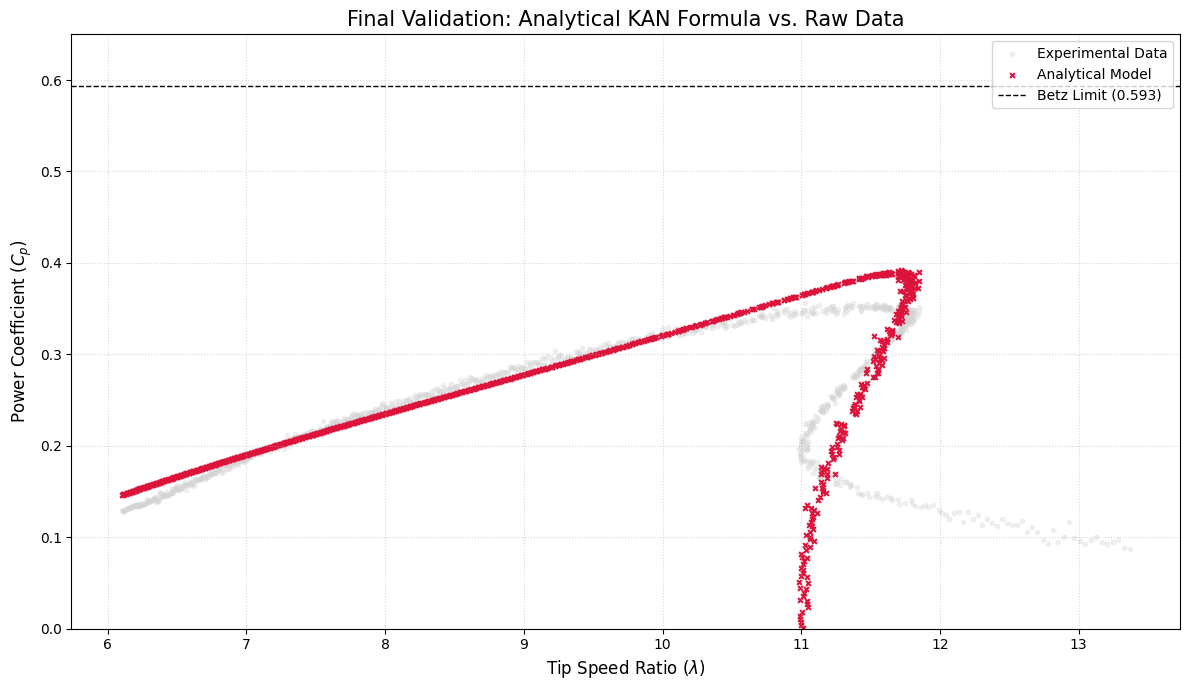

In [29]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1. Standardize the 'theta' symbol to avoid Case-Sensitivity issues
# We replace whatever 'theta' variant is in the formula with our symbolic Theta
# Also find the symbol for pi if it's symbolic
all_symbols = cp_final.free_symbols
symbol_map = {s: Theta for s in all_symbols if s.name.lower() == 'theta'}
cp_fixed = cp_final.subs(symbol_map)

# 2. Create the numerical function
# We explicitly map 'exp' and 'pi' to numpy versions to avoid 'Mul' errors
cp_func_numerical = sp.lambdify(
    (Lambda, V, R, rho, P_max, Theta), 
    cp_fixed, 
    modules=['numpy']
)

# 3. Prepare numerical data
V_vals = data[:, 0]
W_vals = data[:, 1]
# Use the constant pitch angle from your experiment (usually 0 for Cp max)
theta_const = 0.0 
theta_input = np.full_like(V_vals, theta_const)
lambda_vals = (W_vals * R_VAL) / V_vals

# 4. Calculate Cp values
# Ensure the order matches (Lambda, V, R, rho, P_max, Theta)
cp_numeric_results = cp_func_numerical(
    lambda_vals, 
    V_vals, 
    R_VAL, 
    RHO_VAL, 
    max_P,
    theta_input
)

# 5. Final Plotting
plt.figure(figsize=(12, 7))

# Plot Baseline Data
plt.scatter(lambda_vals, cp_real, color='lightgray', alpha=0.3, s=10, label="Experimental Data")

# Plot The Analytical KAN Formula
plt.scatter(lambda_vals, cp_numeric_results, color='crimson', s=12, marker='x', label="Analytical Model")

# Physics & Aesthetics
plt.axhline(y=0.593, color='black', linestyle='--', linewidth=1, label='Betz Limit (0.593)')
plt.title('Final Validation: Analytical KAN Formula vs. Raw Data', fontsize=15)
plt.xlabel(r'Tip Speed Ratio ($\lambda$)', fontsize=12)
plt.ylabel(r'Power Coefficient ($C_p$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.ylim(0, 0.65)

plt.tight_layout()
plt.show()

In [30]:
# Посмотреть на "чистую" формулу перед отрисовкой
from IPython.display import display
display(cp_final)

2*P_max*(0.265170216560364 + 1.1764874458313*exp(-2.91464263249609*(-0.0636287120543895*V + 1 + 0.0545970174575092*V*lambda/R)**2) - 0.529882729053497/(0.00273201942854376*exp(2.47365475139559*theta + 3.43249815551175*V*lambda/R) + 1))/(pi*R**2*V**3*rho)

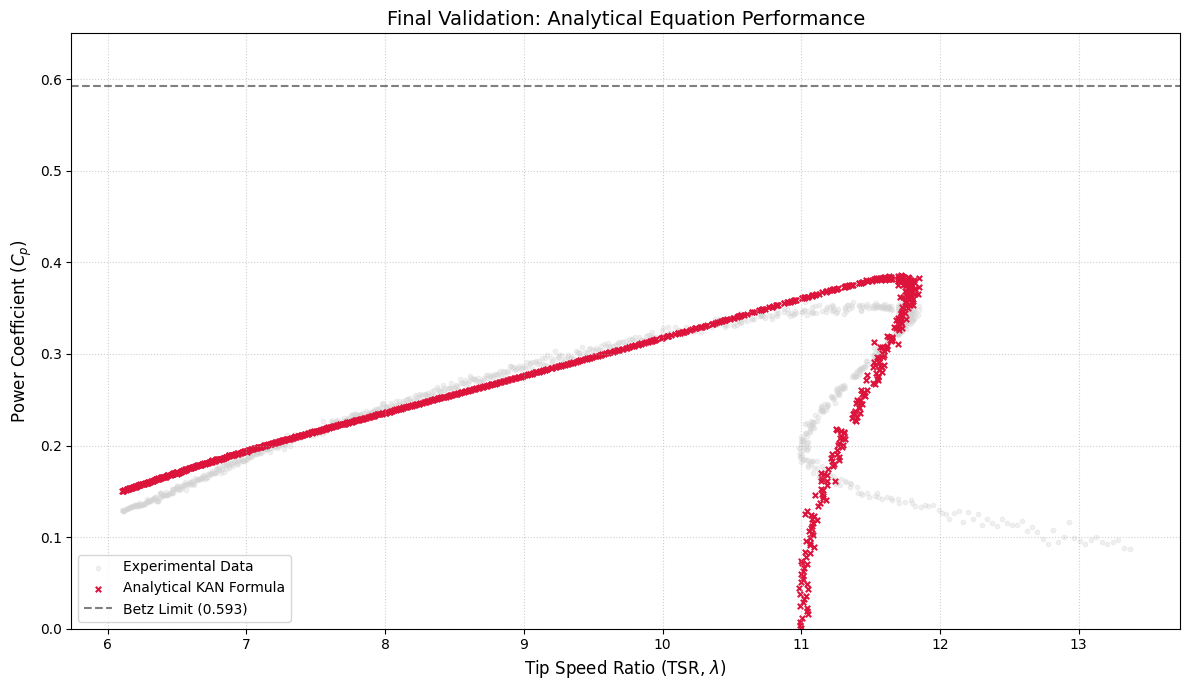

CLEAN SYMBOLIC FORMULA:


2*P_max*(0.265170216560364 + 1.1764874458313*exp(-2.91464263249609*(-0.0636287120543895*V + 1 + 0.0545970174575092*V*lambda/R)**2) - 0.529882729053497/(0.00273201942854376*exp(2.47365475139559*Theta + 3.43249815551175*V*lambda/R) + 1))/(pi*R**2*V**3*rho)

In [31]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1. Clean the formula symbols to match our variables
# We find all symbols like 'lambda_' or 'theta' and map them to our standard ones
all_syms = cp_final.free_symbols
mapping = {}
for s in all_syms:
    if s.name.lower().startswith('lambda'):
        mapping[s] = Lambda
    elif s.name.lower() == 'theta':
        mapping[s] = Theta

cp_cleaned = cp_final.subs(mapping)

# 2. Create the numerical function with explicit mapping to NumPy
# We pass all symbols found in the cleaned formula as arguments
cp_func = sp.lambdify((V, Lambda, Theta, R, rho, P_max), cp_cleaned, modules=['numpy'])

# 3. Prepare data for the plot
v_vals = data[:, 0]
w_vals = data[:, 1]
t_vals = data[:, 2] # Pitch angle (theta)
tsr_vals = (w_vals * R_VAL) / v_vals # TSR (lambda)

# 4. Calculate numerical results
# Ensure the order matches: (V, Lambda, Theta, R, rho, P_max)
cp_results = cp_func(v_vals, tsr_vals, t_vals, R_VAL, RHO_VAL, max_P)

# 5. Final Visualization
plt.figure(figsize=(12, 7))

# Plot Baseline
plt.scatter(tsr_vals, cp_real, color='lightgray', alpha=0.3, s=10, label='Experimental Data')

# Plot KAN Formula
plt.scatter(tsr_vals, cp_results, color='crimson', s=15, marker='x', label='Analytical KAN Formula')

# Physics Limits
plt.axhline(y=0.593, color='black', linestyle='--', alpha=0.5, label='Betz Limit (0.593)')

plt.title('Final Validation: Analytical Equation Performance', fontsize=14)
plt.xlabel(r'Tip Speed Ratio (TSR, $\lambda$)', fontsize=12)
plt.ylabel(r'Power Coefficient ($C_p$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(0, 0.65)

plt.tight_layout()
plt.show()

# Export clean formula
print("CLEAN SYMBOLIC FORMULA:")
display(cp_cleaned)

In [32]:
plt.savefig('80721_final.png', dpi=300, bbox_inches='tight') # Сохраняем

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig('80721_final_1.png', dpi=80, bbox_inches='tight') 

<Figure size 640x480 with 0 Axes>